## Pergunta de Pesquisa

Filmes com maior bilheteria doméstica tendem a ter maior bilheteria mundial?

## Descrição dos Dados

Para responder a essa pergunta, utilizamos um dataset contendo informações financeiras sobre filmes. As principais colunas analisadas são:

- **Domestic Sales**: representa a bilheteria arrecadada no mercado doméstico.
- **International Sales**: representa a bilheteria arrecadada fora do mercado doméstico.
- **Worldwide Sales**: corresponde à soma das bilheterias doméstica e internacional, indicando o total arrecadado globalmente.
- **Domestic Opening**: refere-se à arrecadação do filme em seu fim de semana de estreia no mercado doméstico.

## Hipótese

A hipótese é que filmes com maiores valores em **Domestic Sales** tendem também a apresentar maiores valores em **Worldwide Sales**, indicando uma possível correlação positiva entre essas variáveis.

## Observações

Além disso, a coluna **Domestic Opening** pode ser utilizada para extrair insights adicionais, como o impacto da estreia no desempenho total do filme. Filmes com uma abertura forte podem ter maior visibilidade e, consequentemente, maior arrecadação ao longo do tempo.

## Objetivo

O objetivo da análise é verificar a existência e a intensidade da relação entre a bilheteria doméstica e a bilheteria mundial.

In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)

list(df.columns)


e:\Cesar\Python\Estatística\TrabalhoEstatistica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_16684\1179833260.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, handle, file_path)


['Unnamed: 0',
 'Title',
 'Movie Info',
 'Year',
 'Distributor',
 'Budget (in $)',
 'Domestic Opening (in $)',
 'Domestic Sales (in $)',
 'International Sales (in $)',
 'World Wide Sales (in $)',
 'Release Date',
 'Genre',
 'Running Time',
 'License']

## Verificação de Dados Faltantes

Antes de iniciar a análise, é importante verificar se existem dados faltantes nas colunas utilizadas:

- **Domestic Sales**
- **International Sales**
- **Worldwide Sales**
- **Domestic Opening**

A presença de valores nulos pode impactar os resultados da análise, por isso essa etapa é necessária para garantir a qualidade dos dados.

In [2]:
df_filtrado = df[['Title','Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']]

df_filtrado.dtypes


Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)         str
dtype: object

É possivel notar que Domestic Opening esta no formato string então é preciso converte ele para um formato de inteiro como as estão nas demais colunas !

In [3]:
print(df_filtrado['Domestic Opening (in $)'])

0       77025481
1      357115007
2      134100226
3       28638131
4      247966675
         ...    
995     35648740
996     29651193
997     15190758
998     20574802
999     30429860
Name: Domestic Opening (in $), Length: 1000, dtype: str


In [12]:
(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()


np.True_

** Aparti dessa analise de regex é possivel notar que existe colunas em Domectic Opeing que contem caracteres diferentes de numeros, o que indica possíveis problemas.

In [4]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']]

,Title,Domestic Opening (in $)
95,"Hi, Mom",2 hr 8 min
148,Detective Chinatown 3,February 12 2021 (China)
279,Moon Man,2 hr 2 min
285,Dying to Survive,1 hr 57 min
317,"My People, My Homeland",2 hr 33 min
344,Gone with the Wind,December 15 1939 (Domestic)
401,Hello Mr. Billionaire,1 hr 58 min
467,Never Say Die,1 hr 40 min
482,Crazy Alien,1 hr 56 min
615,Bambi,August 21 1942 (Domestic)


In [17]:
df.loc[~df['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$'),['Title', 'Domestic Opening (in $)']].shape[0]

28

## Tratamento de Valores Inconsistentes

A partir da análise utilizando expressões regulares (regex), foi identificado que a coluna **Domestic Opening (in $)** contém valores que não seguem o padrão esperado de dados numéricos.

Foram encontrados **28 registros** com valores inconsistentes, incluindo informações como tempo de duração do filme (ex: "2 hr 8 min") e datas de lançamento, o que indica um erro ou inconsistência no dataset.

Esses valores não são relevantes para a análise proposta e podem comprometer os resultados estatísticos.

## Decisão de Tratamento

Dado que a quantidade de registros inválidos é relativamente pequena em relação ao total de dados, a estratégia adotada será a **remoção dessas linhas** do DataFrame.

Essa abordagem garante que a análise seja realizada apenas com dados válidos e confiáveis, sem introduzir distorções nos resultados.

In [6]:
df_filtrado = df_filtrado[df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')]

(~df_filtrado['Domestic Opening (in $)'].str.match(r'^[\d\$,]+$')).any()

np.False_

In [5]:
print("Antes:", df.shape[0])
print("Depois:", df_filtrado.shape[0])

Antes: 1000
Depois: 1000


## Remoção de Dados Inconsistentes

Após a identificação de valores inconsistentes na coluna **Domestic Opening (in $)**, foi realizada a remoção dessas entradas do DataFrame.

A remoção desses registros garante que o conjunto de dados utilizado seja composto apenas por valores válidos e adequados para análise.

In [21]:
df_filtrado['Domestic Opening (in $)'] = df_filtrado['Domestic Opening (in $)'].astype('int64')

df_filtrado.dtypes

Title                           str
Domestic Sales (in $)         int64
International Sales (in $)    int64
World Wide Sales (in $)       int64
Domestic Opening (in $)       int64
dtype: object

In [28]:
cols = ['Domestic Sales (in $)','International Sales (in $)','World Wide Sales (in $)','Domestic Opening (in $)']
(df_filtrado[cols] < 0).any()

Domestic Sales (in $)         False
International Sales (in $)    False
World Wide Sales (in $)       False
Domestic Opening (in $)       False
dtype: bool

## Verificação de Valores Negativos

Foi realizada a verificação de valores negativos nas principais colunas numéricas do dataset.

Não foram encontrados valores negativos, portanto não foi necessário realizar tratamento adicional.

In [9]:
df_filtrado.describe()

,Domestic Sales (in $),International Sales (in $),World Wide Sales (in $)
count,9.720000e+02,9.720000e+02,9.720000e+02
mean,1.622744e+08,2.639542e+08,4.264058e+08
std,1.169126e+08,2.145428e+08,3.080309e+08
min,1.805800e+04,2.450000e+07,1.799689e+08
25%,9.464145e+07,1.310459e+08,2.280909e+08
50%,1.328338e+08,1.932899e+08,3.215637e+08
75%,1.937921e+08,3.162972e+08,4.909723e+08
max,9.366622e+08,2.138484e+09,2.923706e+09


<Axes: >

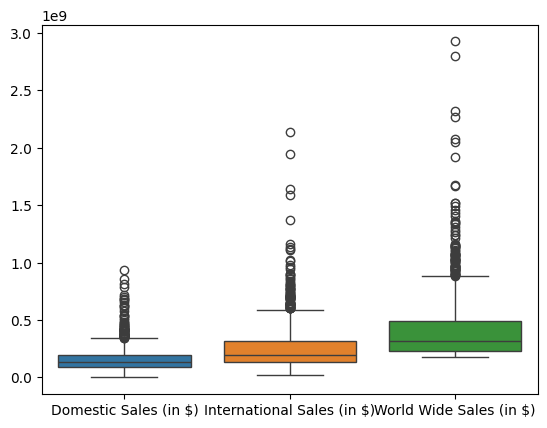

In [10]:
import seaborn as sns
sns.boxplot(data=df_filtrado)

Detectando outliers via z-score

In [31]:
from scipy.stats import zscore

df_filtrado['zscore_worldwide'] = zscore(df_filtrado['World Wide Sales (in $)'])
outliers = df_filtrado[df_filtrado['zscore_worldwide'].abs() > 3]
outliers[['Title', 'World Wide Sales (in $)', 'zscore_worldwide']]

,Title,World Wide Sales (in $),zscore_worldwide
0,Avatar,2923706026,8.111477
1,Avengers: Endgame,2799439100,7.707846
2,Avatar: The Way of Water,2320250281,6.151394
3,Titanic,2264743305,5.971102
4,Star Wars: Episode VII - The Force Awakens,2071310218,5.342812
5,Avengers: Infinity War,2052415039,5.281438
6,Spider-Man: No Way Home,1921847111,4.857341
7,Jurassic World,1671537444,4.044310
8,The Lion King,1663075401,4.016825
9,The Avengers,1520538536,3.553851


# 📊 Análise Exploratória e Relação entre Bilheterias

## Distribuição das Variáveis

Inicialmente, analisamos a distribuição das principais variáveis financeiras dos filmes:

- **Domestic Sales**
- **International Sales**
- **Worldwide Sales**
- **Domestic Opening**

O objetivo é entender como os dados estão distribuídos, identificar possíveis assimetrias (skewness) e detectar a presença de outliers, comuns em datasets de bilheteria devido a grandes blockbusters.

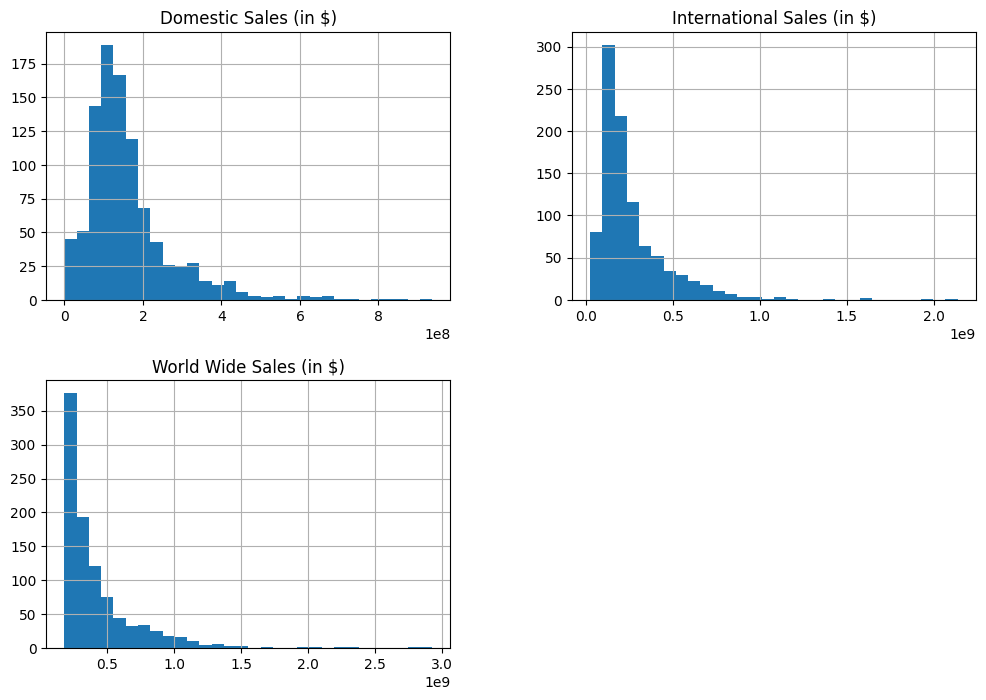

In [ ]:
cols = [
    'Domestic Sales (in $)',
    'International Sales (in $)',
    'World Wide Sales (in $)',
    'Domestic Opening (in $)'
]

df_filtrado[cols].hist(bins=30, figsize=(12,8))
plt.show()

## Relação entre Bilheteria Doméstica e Mundial

Em seguida, utilizamos um gráfico de dispersão para visualizar a relação entre Domestic Sales e Worldwide Sales.

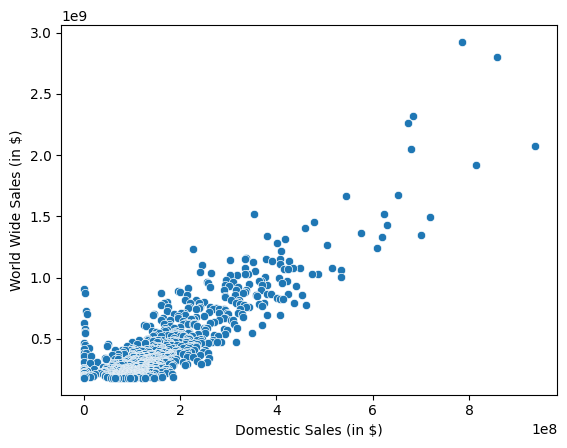

In [14]:
sns.scatterplot(
    data=df_filtrado,
    x='Domestic Sales (in $)',
    y='World Wide Sales (in $)'
)
plt.show()

## Correlação de Pearson (Relação Linear)

Calculamos o coeficiente de correlação de Pearson para medir a força da relação linear entre as variáveis.

In [ ]:
pearson_corr, p_value = pearsonr(
    df_filtrado['Domestic Sales (in $)'],
    df_filtrado['World Wide Sales (in $)']
)

print("Pearson:", pearson_corr)
print("p-value:", p_value)

Pearson: 0.8675212745914206
p-value: 1.8823023919624986e-296


Valores próximos de 1 indicam forte correlação positiva
O p-value indica a significância estatística da correlação

## Correlação de Spearman (Relação Monótona)

Para complementar, utilizamos a correlação de Spearman, que é menos sensível a outliers e capta relações monotônicas.

In [ ]:
spearman_corr, _ = spearmanr(
    df_filtrado['Domestic Sales (in $)'],
    df_filtrado['World Wide Sales (in $)']
)

print("Spearman:", spearman_corr)

Spearman: 0.7509559310227784


## Matriz de Correlação

Analisamos a correlação entre todas as variáveis numéricas do dataset.

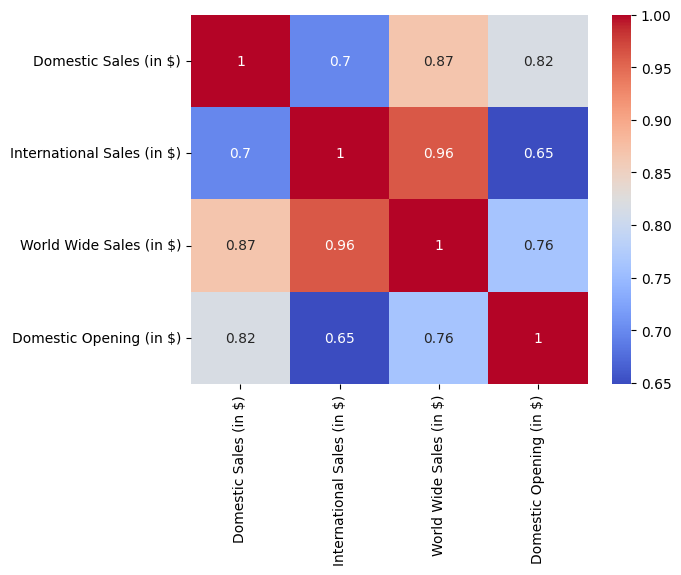

In [18]:
sns.heatmap(
    df_filtrado[cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

Essa visualização permite identificar:

Relações fortes entre variáveis
Possíveis redundâncias (ex: Worldwide já inclui Domestic + International)

## Regressão Linear

Aplicamos uma regressão linear para visualizar a tendência entre as variáveis e entender melhor o comportamento dos dados.

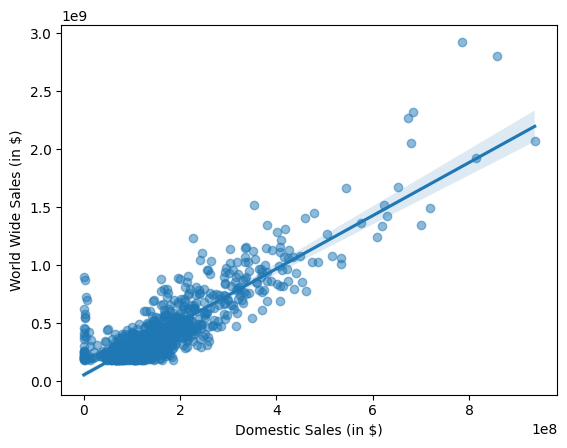

In [19]:
sns.regplot(
    data=df_filtrado,
    x='Domestic Sales (in $)',
    y='World Wide Sales (in $)',
    scatter_kws={'alpha':0.5}
)
plt.show()

## Análise da Proporção Internacional

Criamos a métrica International Ratio, que representa a proporção da bilheteria mundial proveniente do mercado internacional.

In [21]:
df_filtrado['International Ratio'] = (
    df_filtrado['International Sales (in $)'] /
    df_filtrado['World Wide Sales (in $)']
)

df_filtrado

,Title,Domestic Sales (in $),International Sales (in $),World Wide Sales (in $),Domestic Opening (in $),International Ratio
0,Avatar,785221649,2138484377,2923706026,77025481,0.731429
1,Avengers: Endgame,858373000,1941066100,2799439100,357115007,0.693377
2,Avatar: The Way of Water,684075767,1636174514,2320250281,134100226,0.705172
3,Titanic,674292608,1590450697,2264743305,28638131,0.702265
4,Star Wars: Episode VII - The Force Awakens,936662225,1134647993,2071310218,247966675,0.547792
...,...,...,...,...,...,...
995,Sweet Home Alabama,127223418,53399006,180622424,35648740,0.295639
996,Daddy's Home 2,104029443,76584381,180613824,29651193,0.424023
997,Hacksaw Ridge,67209615,113354021,180563636,15190758,0.627779
998,Deja Vu,64038616,116518934,180557550,20574802,0.645329


## Estatísticas do International Ratio

Calculamos a média e o desvio padrão dessa proporção.

In [24]:
mean = df_filtrado['International Ratio'].mean()
std = df_filtrado['International Ratio'].std()

print("Média:", mean)
print("Desvio padrão:", std)

Média: 0.6027747217459826
Desvio padrão: 0.14928359607296088


## Distribuição do International Ratio

Por fim, analisamos a distribuição do International Ratio.

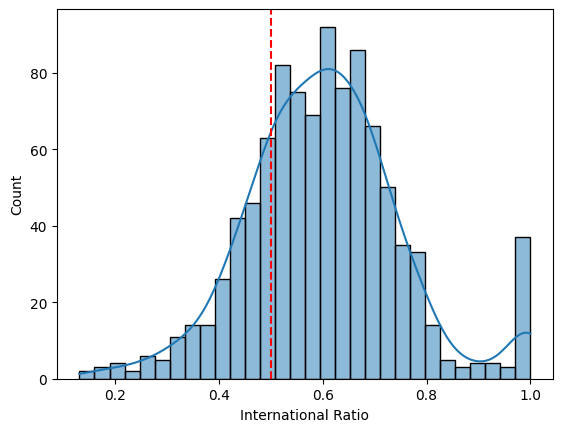

In [ ]:
sns.histplot(df_filtrado['International Ratio'], bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--')
plt.show()

A linha em 0.5 representa um equilíbrio entre mercado doméstico e internacional.

Essa análise permite identificar:

Se os filmes tendem a ser mais globais ou domésticos
A existência de diferentes perfis de distribuição de receita

# 🧾 Conclusão da Análise

## 🎯 Relação entre Bilheteria Doméstica e Mundial

Os resultados indicam uma **forte correlação positiva** entre a bilheteria doméstica (**Domestic Sales**) e a bilheteria mundial (**Worldwide Sales**).

- **Correlação de Pearson:** 0.8675  
- **p-value:** ~0 (extremamente significativo)

Isso demonstra que existe uma **relação linear forte e estatisticamente significativa** entre as variáveis, ou seja, filmes com maior arrecadação doméstica tendem, de fato, a apresentar maior arrecadação global.

A correlação de **Spearman (0.7510)** reforça esse resultado, indicando que essa relação também se mantém de forma consistente mesmo quando considerada apenas a ordem dos dados (relação monotônica), sendo menos sensível a outliers.

---

## 🌍 Influência do Mercado Internacional

A correlação entre **Domestic Sales** e **International Sales (~0.7)** indica uma relação positiva moderada a forte, sugerindo que filmes bem-sucedidos no mercado doméstico tendem também a performar bem internacionalmente, embora com maior variabilidade.

---

## 📊 Dependência do Mercado Internacional

A análise do **International Ratio** revelou:

- **Média:** 0.603  
- **Desvio padrão:** 0.149  

Isso indica que, em média, aproximadamente **60% da bilheteria mundial dos filmes provém do mercado internacional**, evidenciando uma forte dependência do mercado externo.

O desvio padrão relativamente moderado sugere que existe variabilidade entre os filmes, mas ainda assim uma **tendência consistente de predominância internacional**.

---

## ⚠️ Impacto dos Outliers (Z-score)

A análise de **z-score** identificou um conjunto de filmes com desempenho extremamente acima da média (**z > 3**), caracterizando outliers significativos no dataset.

Entre eles destacam-se:

- *Avatar* (z ≈ 8.11)  
- *Avengers: Endgame* (z ≈ 7.71)  
- *Avatar: The Way of Water* (z ≈ 6.15)  
- *Titanic* (z ≈ 5.97)  
- *Star Wars: The Force Awakens* (z ≈ 5.34)  

Esses filmes representam **casos excepcionais de sucesso global**, com arrecadações muito acima do padrão observado.

A presença desses outliers indica que:

- A distribuição de bilheterias é **altamente assimétrica (right-skewed)**  
- Poucos filmes concentram uma parcela desproporcional da receita total  
- Esses valores extremos influenciam fortemente métricas como média e correlação  

---

## 🧠 Interpretação Geral

Os resultados permitem concluir que:

- Existe uma **relação forte entre desempenho doméstico e global**
- O mercado internacional desempenha um papel **predominante na receita total**
- A indústria cinematográfica apresenta uma estrutura **altamente desigual**, onde poucos filmes dominam a arrecadação

---

## 🚀 Insight Final

Embora o sucesso doméstico seja um bom indicador de sucesso global, a análise mostra que:

> O desempenho internacional é um fator determinante e amplificador do sucesso global, enquanto poucos filmes extraordinários (outliers) dominam o mercado e influenciam significativamente as análises estatísticas.